In [12]:
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

In [13]:
file_path = "../datasets/credit_risk_dataset.csv"
df = pd.read_csv(file_path)
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


#### Performing EDA on the Dataset

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [15]:
# checking for missing values
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [16]:
# checking for unique values in each column
df.nunique()

person_age                      58
person_income                 4295
person_home_ownership            4
person_emp_length               36
loan_intent                      6
loan_grade                       7
loan_amnt                      753
loan_int_rate                  348
loan_status                      2
loan_percent_income             77
cb_person_default_on_file        2
cb_person_cred_hist_length      29
dtype: int64

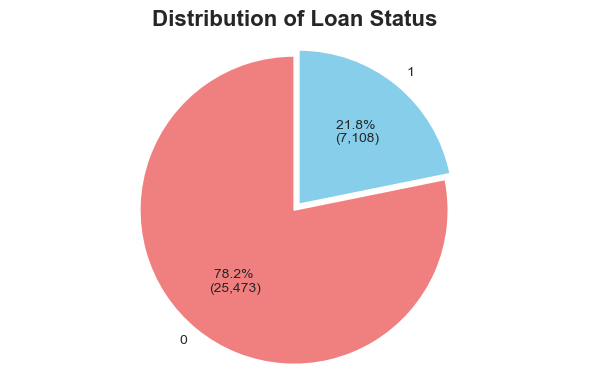

Loan Status Distribution:
0: 25473 (78.2%)
1: 7108 (21.8%)


In [17]:
# creating a pie chart for loan_status distribution
plt.figure(figsize=(6, 4))
loan_status_counts = df['loan_status'].value_counts()

# function to show both percentage and count
def autopct_format(pct):
    absolute = int(pct / 100. *len(df))
    return f'{pct:.1f}% \n({absolute:,})'

plt.pie(
    loan_status_counts.values,
    labels=loan_status_counts.index,
    autopct=autopct_format,
    startangle=90,
    colors=['lightcoral', 'skyblue'],
    explode=(0.05, 0)
)

plt.title('Distribution of Loan Status', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

# printing the actual counts for reference
print(f"Loan Status Distribution:")
for status, count in loan_status_counts.items():
    percentage = (count / len(df)) * 100
    print(f"{status}: {count} ({percentage:.1f}%)")

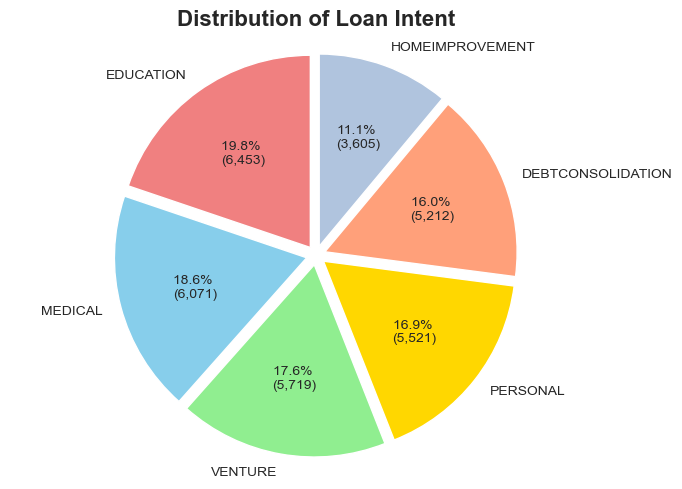

In [18]:
# creating a pie chart for loan_intent distribution
plt.figure(figsize=(7, 5))
loan_intent_counts = df['loan_intent'].value_counts()

def autopct_format_intent(pct):
    absolute = int(pct/100.*len(df))
    return f'{pct:.1f}% \n({absolute:,})'

colors = ['lightcoral', 'skyblue', 'lightgreen', 'gold', 'lightsalmon', 'lightsteelblue']

plt.pie(
    loan_intent_counts.values,
    labels=loan_intent_counts.index,
    autopct=autopct_format_intent,
    startangle=90,
    colors=colors[:len(loan_intent_counts)],
    explode=[0.05] * len(loan_intent_counts)
)

plt.title('Distribution of Loan Intent', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Correlation Matrix')

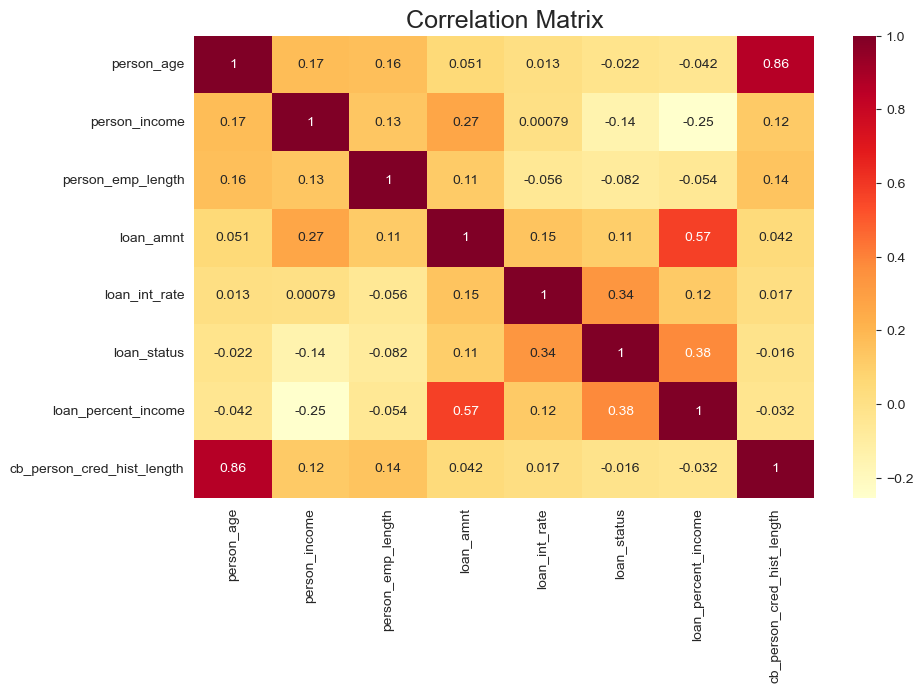

In [19]:
# visualizing the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='YlOrRd')
plt.title('Correlation Matrix', fontsize=18)

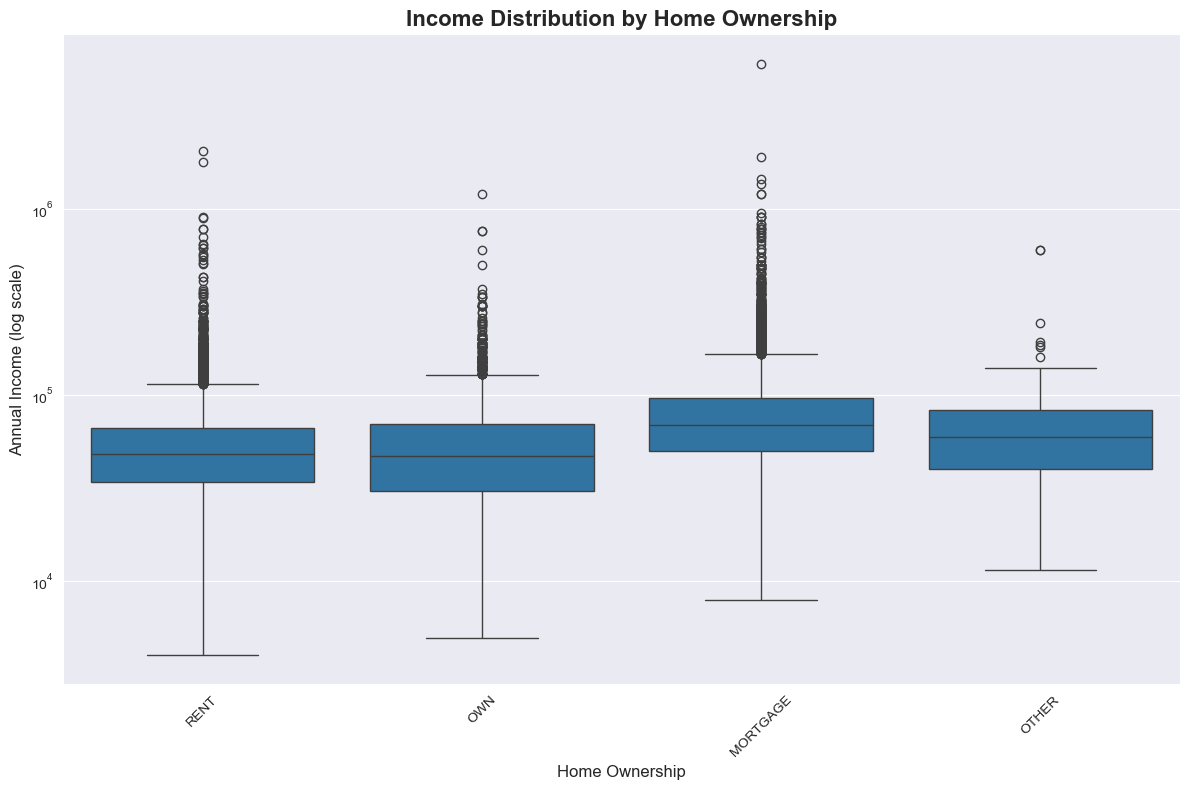


Income Summary by Home Ownership:

RENT:
  Median: $48,000.00
  Mean: $54,997.75
  Count: 16,446

OWN:
  Median: $47,000.00
  Mean: $57,834.81
  Count: 2,584

MORTGAGE:
  Median: $69,000.00
  Mean: $81,127.12
  Count: 13,444

OTHER:
  Median: $59,000.00
  Mean: $76,387.80
  Count: 107


In [20]:
# creating a box plot for income distribution by home ownership
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='person_home_ownership', y='person_income')

# setting y-axis to log scale for better visualization due to wide income range
plt.yscale('log')

plt.title('Income Distribution by Home Ownership', fontsize=16, fontweight='bold')
plt.xlabel('Home Ownership', fontsize=12)
plt.ylabel('Annual Income (log scale)', fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# printing summary statistics for each home ownership category
print("\nIncome Summary by Home Ownership:")
for ownership in df['person_home_ownership'].unique():
    subset = df[df['person_home_ownership'] == ownership]['person_income']
    print(f"\n{ownership}:")
    print(f"  Median: ${subset.median():,.2f}")
    print(f"  Mean: ${subset.mean():,.2f}")
    print(f"  Count: {len(subset):,}")

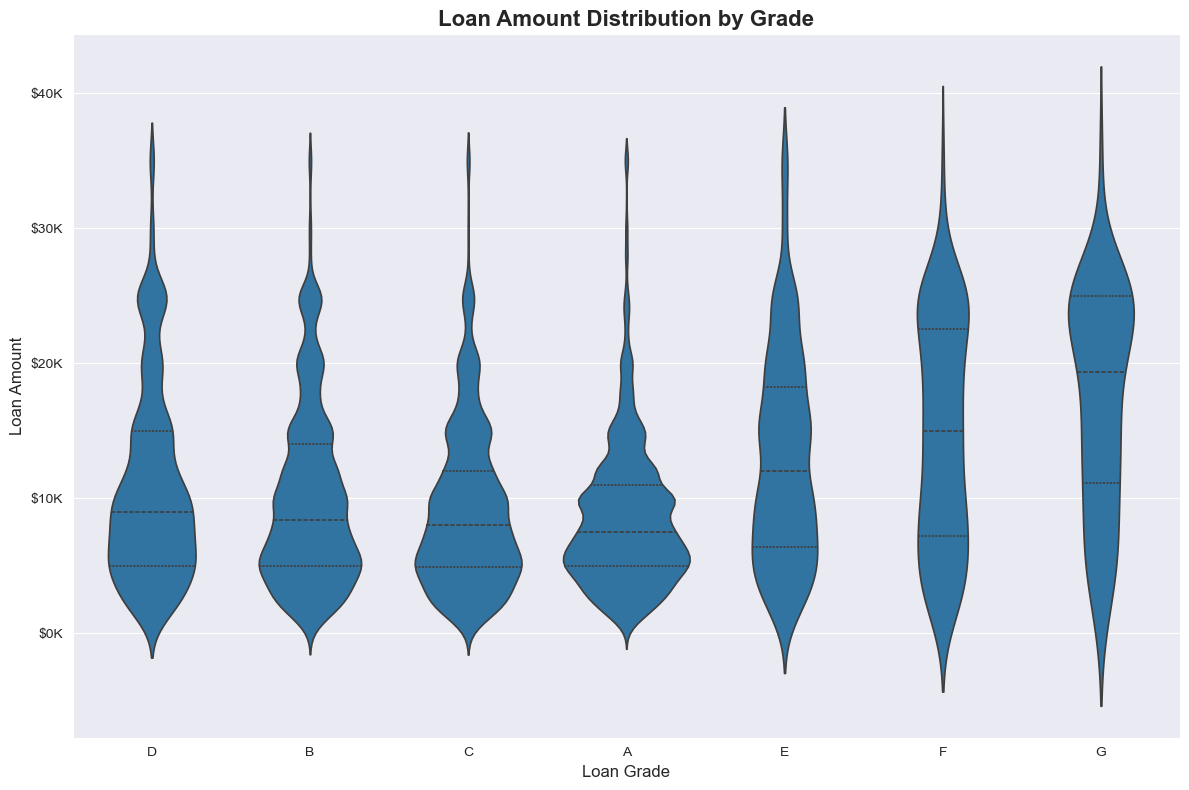


Loan Amount Summary by Grade:

Grade A:
  Median: $7,500.00
  Mean: $8,539.27
  Count: 10,777
  Range: $500.00 - $35,000.00

Grade B:
  Median: $8,400.00
  Mean: $9,995.48
  Count: 10,451
  Range: $500.00 - $35,000.00

Grade C:
  Median: $8,000.00
  Mean: $9,213.86
  Count: 6,458
  Range: $500.00 - $35,000.00

Grade D:
  Median: $9,000.00
  Mean: $10,849.24
  Count: 3,626
  Range: $1,000.00 - $35,000.00

Grade E:
  Median: $12,000.00
  Mean: $12,915.85
  Count: 964
  Range: $1,000.00 - $35,000.00

Grade F:
  Median: $15,000.00
  Mean: $14,717.32
  Count: 241
  Range: $1,200.00 - $35,000.00

Grade G:
  Median: $19,375.00
  Mean: $17,195.70
  Count: 64
  Range: $1,600.00 - $35,000.00


In [21]:
# creating a violin plot for loan amount distribution by loan grade
plt.figure(figsize=(12, 8))
sns.violinplot(data=df, x='loan_grade', y='loan_amnt', inner='quartile')

plt.title('Loan Amount Distribution by Grade', fontsize=16, fontweight='bold')
plt.xlabel('Loan Grade', fontsize=12)
plt.ylabel('Loan Amount', fontsize=12)

# formatting y-axis to show values in thousands
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.show()

# printing summary statistics for each loan grade
print("\nLoan Amount Summary by Grade:")
for grade in sorted(df['loan_grade'].unique()):
    subset = df[df['loan_grade'] == grade]['loan_amnt']
    print(f"\nGrade {grade}:")
    print(f"  Median: ${subset.median():,.2f}")
    print(f"  Mean: ${subset.mean():,.2f}")
    print(f"  Count: {len(subset):,}")
    print(f"  Range: ${subset.min():,.2f} - ${subset.max():,.2f}")

In [22]:
# dropping null values since they are very few as compared to dataset size
df.dropna(axis=0, inplace=True)
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [23]:
df.shape

(28638, 12)

In [24]:
# checking the distribution of the target variable after dropping null values
df['loan_status'].value_counts()

loan_status
0    22435
1     6203
Name: count, dtype: int64

In [25]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,28638.000000,2.863800e+04,28638.000000,28638.000000,28638.000000,28638.000000,28638.000000,28638.000000
mean,27.727216,6.664937e+04,4.788672,9656.493121,11.039867,0.216600,0.169488,5.793736
std,6.310441,6.235645e+04,4.154627,6329.683361,3.229372,0.411935,0.106393,4.038483
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.948000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.595600e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.480000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


<Axes: xlabel='person_age', ylabel='Count'>

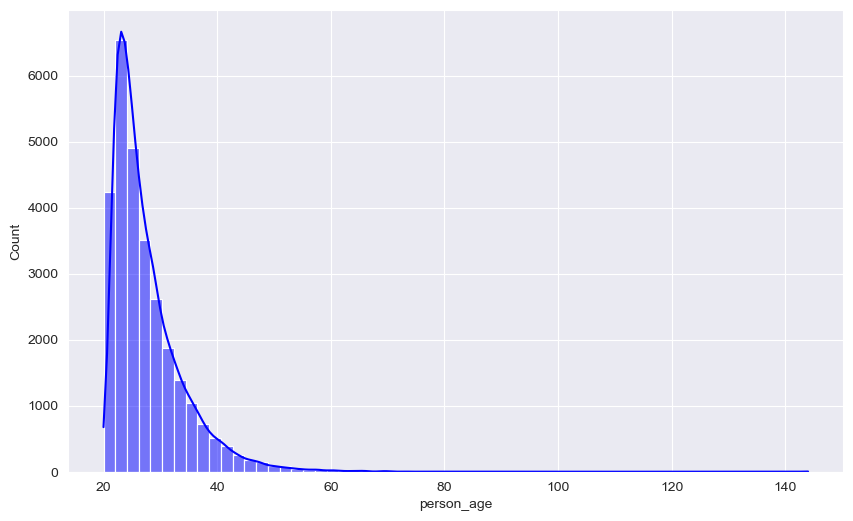

In [26]:
# checking the distribution of ages
plt.figure(figsize=(10, 6))
sns.histplot(df['person_age'], bins=60, kde=True, color='blue')

In [27]:
df['person_age'].value_counts().sort_index(ascending=False).head(10)

person_age
144    3
123    1
84     1
80     1
78     1
76     1
73     2
70     5
69     5
67     1
Name: count, dtype: int64

We see that there's some unknown values for age, such as 144. For this reason, it's safe to drop values where age of the person is greater than 80, as most likely they won't be applying for loan considering the age.

#### Feature Engineering

In [28]:
# dropping ages greater than 80 as they are outliers
df = df[df['person_age'] <= 80]
df.shape

(28633, 12)

In [29]:
# creating age groups
df['age_group'] = pd.cut(
    df['person_age'],
    bins=[20, 26, 36, 46, 56, 66],
    labels=['20-25', '26-35', '36-45', '46-55', '56-65']
)

# creating income groups
df['income_group'] = pd.cut(
    df['person_income'],
    bins=[0, 25000, 50000, 75000, 100000, float('inf')],
    labels=['low', 'low-middle', 'middle', 'high-middle', 'high']
)

# creating loan amount groups
df['loan_amount_group'] = pd.cut(
    df['loan_amnt'],
    bins=[0, 5000, 10000, 15000, float('inf')],
    labels=['small', 'medium', 'large', 'very large']
)

##### Visualizations Supporting Feature Engineering Decisions

C:\Users\isha1\AppData\Local\Temp\ipykernel_24760\3595387956.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_default_rate = df.groupby('age_group')['loan_status'].mean()


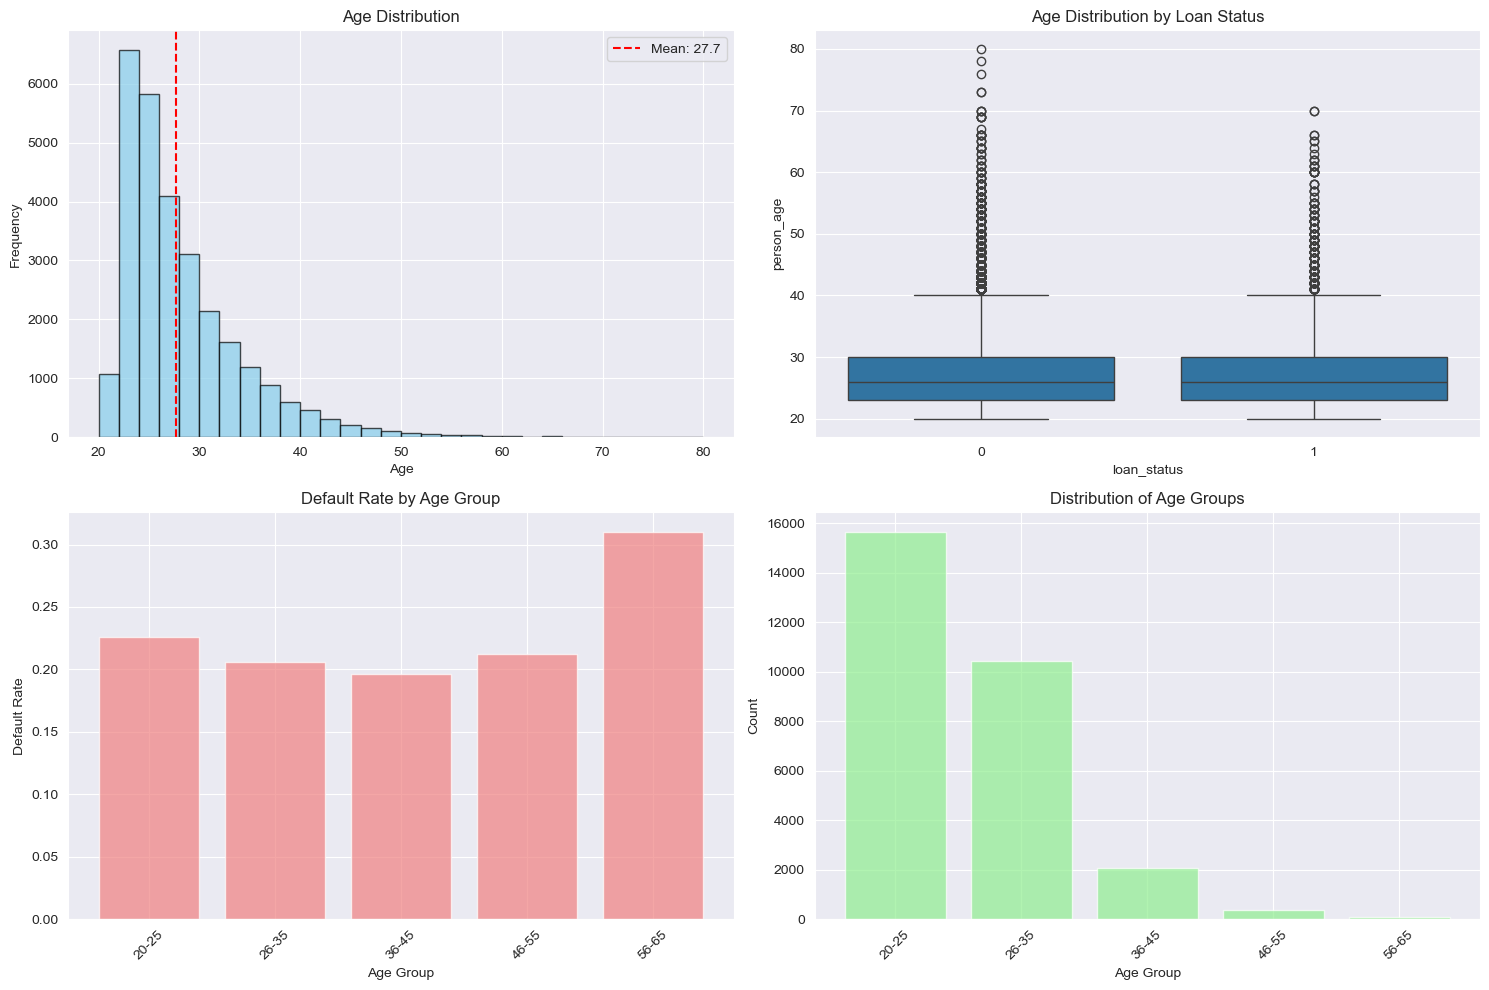

In [30]:
# 1. Age Distribution Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Age histogram
axes[0,0].hist(df['person_age'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].axvline(df['person_age'].mean(), color='red', linestyle='--', label=f'Mean: {df["person_age"].mean():.1f}')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Age vs Loan Status
sns.boxplot(data=df, x='loan_status', y='person_age', ax=axes[0,1])
axes[0,1].set_title('Age Distribution by Loan Status')

# Age groups vs Default Rate
age_default_rate = df.groupby('age_group')['loan_status'].mean()
axes[1,0].bar(age_default_rate.index, age_default_rate.values, color='lightcoral', alpha=0.7)
axes[1,0].set_title('Default Rate by Age Group')
axes[1,0].set_xlabel('Age Group')
axes[1,0].set_ylabel('Default Rate')
axes[1,0].tick_params(axis='x', rotation=45)

# Age group distribution
age_group_counts = df['age_group'].value_counts().sort_index()
axes[1,1].bar(age_group_counts.index, age_group_counts.values, color='lightgreen', alpha=0.7)
axes[1,1].set_title('Distribution of Age Groups')
axes[1,1].set_xlabel('Age Group')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

C:\Users\isha1\AppData\Local\Temp\ipykernel_24760\3282559606.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_default_rate = df.groupby('income_group')['loan_status'].mean()


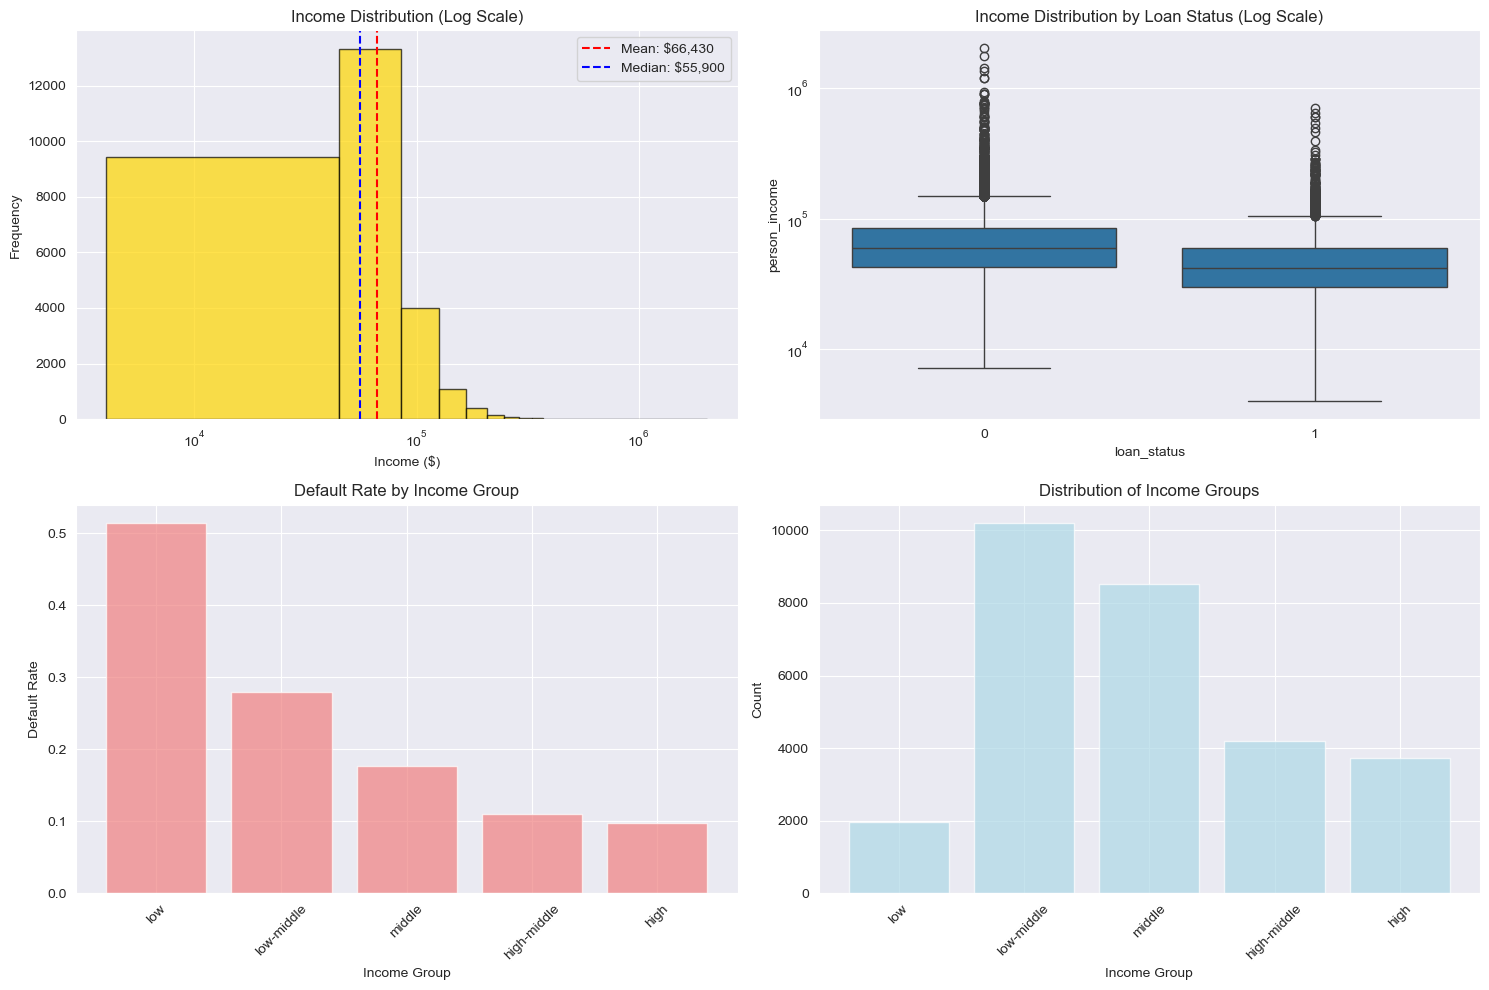

In [31]:
# 2. Income Distribution Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Income histogram (log scale)
axes[0,0].hist(df['person_income'], bins=50, alpha=0.7, color='gold', edgecolor='black')
axes[0,0].set_xscale('log')
axes[0,0].axvline(df['person_income'].mean(), color='red', linestyle='--', label=f'Mean: ${df["person_income"].mean():,.0f}')
axes[0,0].axvline(df['person_income'].median(), color='blue', linestyle='--', label=f'Median: ${df["person_income"].median():,.0f}')
axes[0,0].set_title('Income Distribution (Log Scale)')
axes[0,0].set_xlabel('Income ($)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Income vs Loan Status
sns.boxplot(data=df, x='loan_status', y='person_income', ax=axes[0,1])
axes[0,1].set_yscale('log')
axes[0,1].set_title('Income Distribution by Loan Status (Log Scale)')

# Income groups vs Default Rate
income_default_rate = df.groupby('income_group')['loan_status'].mean()
axes[1,0].bar(income_default_rate.index, income_default_rate.values, color='lightcoral', alpha=0.7)
axes[1,0].set_title('Default Rate by Income Group')
axes[1,0].set_xlabel('Income Group')
axes[1,0].set_ylabel('Default Rate')
axes[1,0].tick_params(axis='x', rotation=45)

# Income group distribution
income_group_counts = df['income_group'].value_counts().sort_index()
axes[1,1].bar(income_group_counts.index, income_group_counts.values, color='lightblue', alpha=0.7)
axes[1,1].set_title('Distribution of Income Groups')
axes[1,1].set_xlabel('Income Group')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

C:\Users\isha1\AppData\Local\Temp\ipykernel_24760\2283908064.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loan_default_rate = df.groupby('loan_amount_group')['loan_status'].mean()


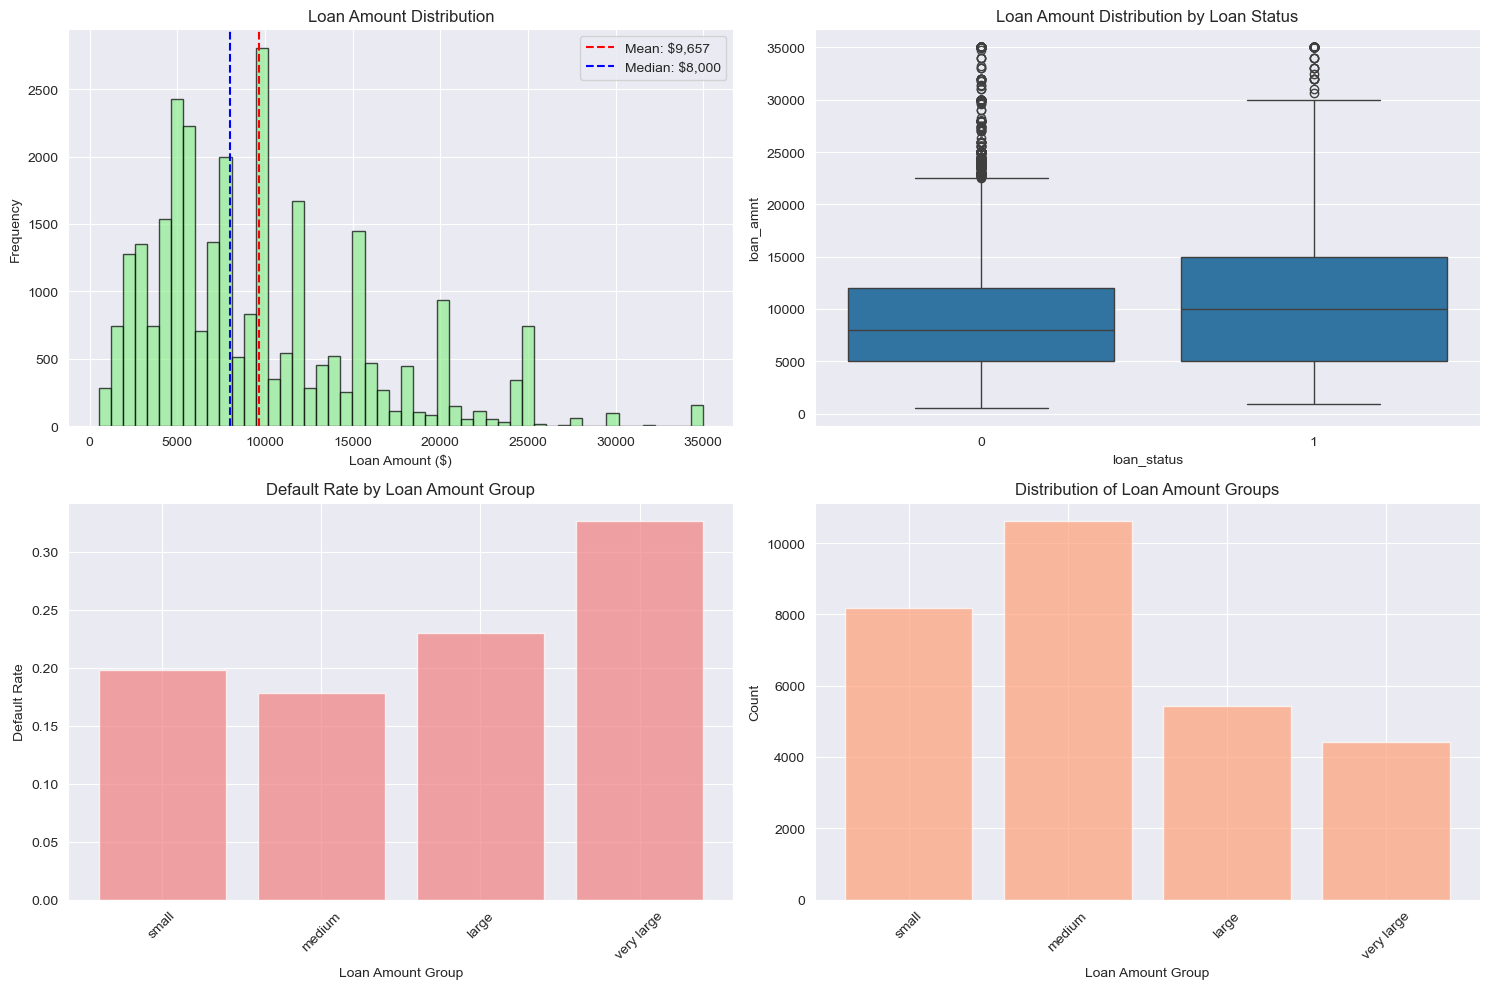

In [32]:
# 3. Loan Amount Distribution Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loan amount histogram
axes[0,0].hist(df['loan_amnt'], bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0,0].axvline(df['loan_amnt'].mean(), color='red', linestyle='--', label=f'Mean: ${df["loan_amnt"].mean():,.0f}')
axes[0,0].axvline(df['loan_amnt'].median(), color='blue', linestyle='--', label=f'Median: ${df["loan_amnt"].median():,.0f}')
axes[0,0].set_title('Loan Amount Distribution')
axes[0,0].set_xlabel('Loan Amount ($)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Loan amount vs Loan Status
sns.boxplot(data=df, x='loan_status', y='loan_amnt', ax=axes[0,1])
axes[0,1].set_title('Loan Amount Distribution by Loan Status')

# Loan amount groups vs Default Rate
loan_default_rate = df.groupby('loan_amount_group')['loan_status'].mean()
axes[1,0].bar(loan_default_rate.index, loan_default_rate.values, color='lightcoral', alpha=0.7)
axes[1,0].set_title('Default Rate by Loan Amount Group')
axes[1,0].set_xlabel('Loan Amount Group')
axes[1,0].set_ylabel('Default Rate')
axes[1,0].tick_params(axis='x', rotation=45)

# Loan amount group distribution
loan_group_counts = df['loan_amount_group'].value_counts().sort_index()
axes[1,1].bar(loan_group_counts.index, loan_group_counts.values, color='lightsalmon', alpha=0.7)
axes[1,1].set_title('Distribution of Loan Amount Groups')
axes[1,1].set_xlabel('Loan Amount Group')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

C:\Users\isha1\AppData\Local\Temp\ipykernel_24760\195943363.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'Age Groups': df.groupby('age_group')['loan_status'].mean(),
C:\Users\isha1\AppData\Local\Temp\ipykernel_24760\195943363.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'Income Groups': df.groupby('income_group')['loan_status'].mean(),
C:\Users\isha1\AppData\Local\Temp\ipykernel_24760\195943363.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the 

Statistical Validation of Feature Engineering Decisions:

1. AGE GROUPS:
   - Natural breaks appear around life stages (young adults, middle-aged, etc.)
   - Default rates vary significantly across age groups
   - 20-25: 15,668 records, 22.6% default rate
   - 26-35: 10,422 records, 20.6% default rate
   - 36-45: 2,054 records, 19.6% default rate
   - 46-55: 372 records, 21.2% default rate
   - 56-65: 87 records, 31.0% default rate

2. INCOME GROUPS:
   - Based on income quantiles and economic classifications
   - Clear inverse relationship with default rates
   - low: $4,000-$25,000, 51.4% default rate
   - low-middle: $25,040-$50,000, 28.0% default rate
   - middle: $50,004-$75,000, 17.7% default rate
   - high-middle: $75,127-$100,000, 11.0% default rate
   - high: $100,010-$2,039,784, 9.8% default rate

3. LOAN AMOUNT GROUPS:
   - Based on loan size categories and risk assessment
   - Relationship with default rates for risk profiling
   - small: $500-$5,000, 19.8% default rate
   

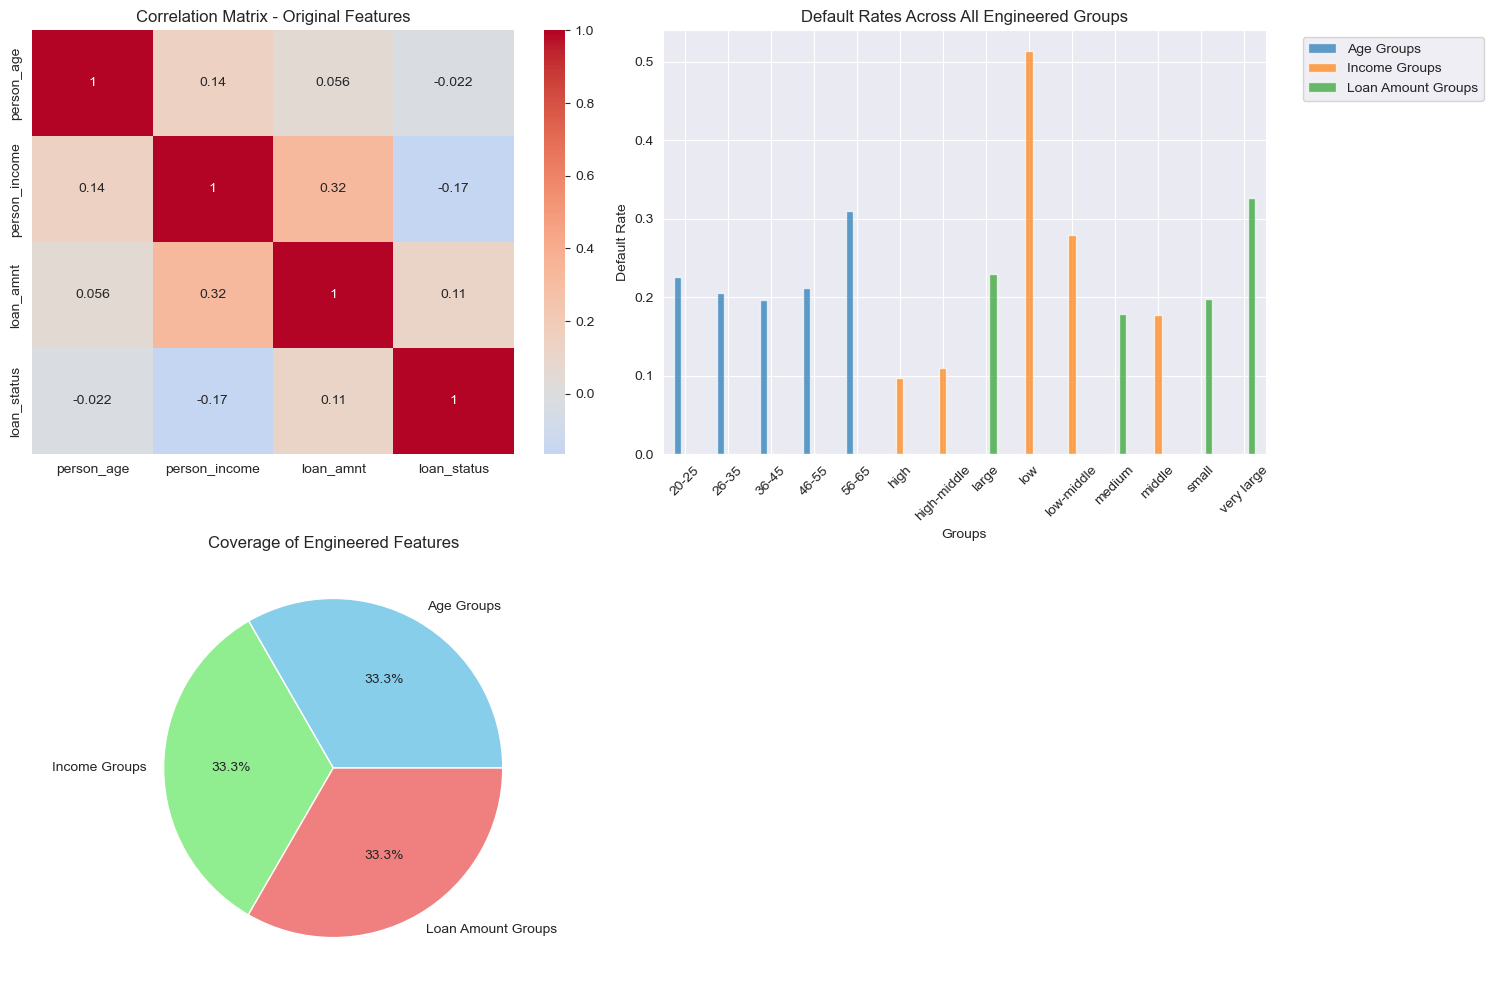

In [33]:
# 4. Summary Analysis - Validation of Feature Engineering
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Correlation heatmap of original vs engineered features
correlation_features = ['person_age', 'person_income', 'loan_amnt', 'loan_status']
corr_matrix = df[correlation_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[0,0])
axes[0,0].set_title('Correlation Matrix - Original Features')

# Default rates by all groups - comparison
group_default_rates = pd.DataFrame({
    'Age Groups': df.groupby('age_group')['loan_status'].mean(),
    'Income Groups': df.groupby('income_group')['loan_status'].mean(),
    'Loan Amount Groups': df.groupby('loan_amount_group')['loan_status'].mean()
})

group_default_rates.plot(kind='bar', ax=axes[0,1], alpha=0.7)
axes[0,1].set_title('Default Rates Across All Engineered Groups')
axes[0,1].set_xlabel('Groups')
axes[0,1].set_ylabel('Default Rate')
axes[0,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0,1].tick_params(axis='x', rotation=45)

# Distribution of records across groups
axes[1,0].pie([len(df[df['age_group'].notna()]),
               len(df[df['income_group'].notna()]),
               len(df[df['loan_amount_group'].notna()])],
              labels=['Age Groups', 'Income Groups', 'Loan Amount Groups'],
              autopct='%1.1f%%',
              colors=['skyblue', 'lightgreen', 'lightcoral'])
axes[1,0].set_title('Coverage of Engineered Features')

# Statistical summary of groupings
print("Statistical Validation of Feature Engineering Decisions:\n")

print("1. AGE GROUPS:")
print("   - Natural breaks appear around life stages (young adults, middle-aged, etc.)")
print("   - Default rates vary significantly across age groups")
for group in df['age_group'].cat.categories:
    group_data = df[df['age_group'] == group]
    default_rate = group_data['loan_status'].mean()
    print(f"   - {group}: {len(group_data):,} records, {default_rate:.1%} default rate")

print("\n2. INCOME GROUPS:")
print("   - Based on income quantiles and economic classifications")
print("   - Clear inverse relationship with default rates")
for group in df['income_group'].cat.categories:
    group_data = df[df['income_group'] == group]
    default_rate = group_data['loan_status'].mean()
    income_range = group_data['person_income'].agg(['min', 'max'])
    print(f"   - {group}: ${income_range['min']:,.0f}-${income_range['max']:,.0f}, {default_rate:.1%} default rate")

print("\n3. LOAN AMOUNT GROUPS:")
print("   - Based on loan size categories and risk assessment")
print("   - Relationship with default rates for risk profiling")
for group in df['loan_amount_group'].cat.categories:
    group_data = df[df['loan_amount_group'] == group]
    default_rate = group_data['loan_status'].mean()
    amount_range = group_data['loan_amnt'].agg(['min', 'max'])
    print(f"   - {group}: ${amount_range['min']:,.0f}-${amount_range['max']:,.0f}, {default_rate:.1%} default rate")

# Remove the unused subplot
axes[1,1].remove()

plt.tight_layout()
plt.show()

In [34]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,age_group,income_group,loan_amount_group
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,20-25,middle,very large
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,20-25,low,small
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,20-25,low,medium
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,20-25,middle,very large
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,20-25,middle,very large


In [35]:
# checking the distribution of home ownership
df['person_home_ownership'].value_counts()

person_home_ownership
RENT        14549
MORTGAGE    11798
OWN          2192
OTHER          94
Name: count, dtype: int64

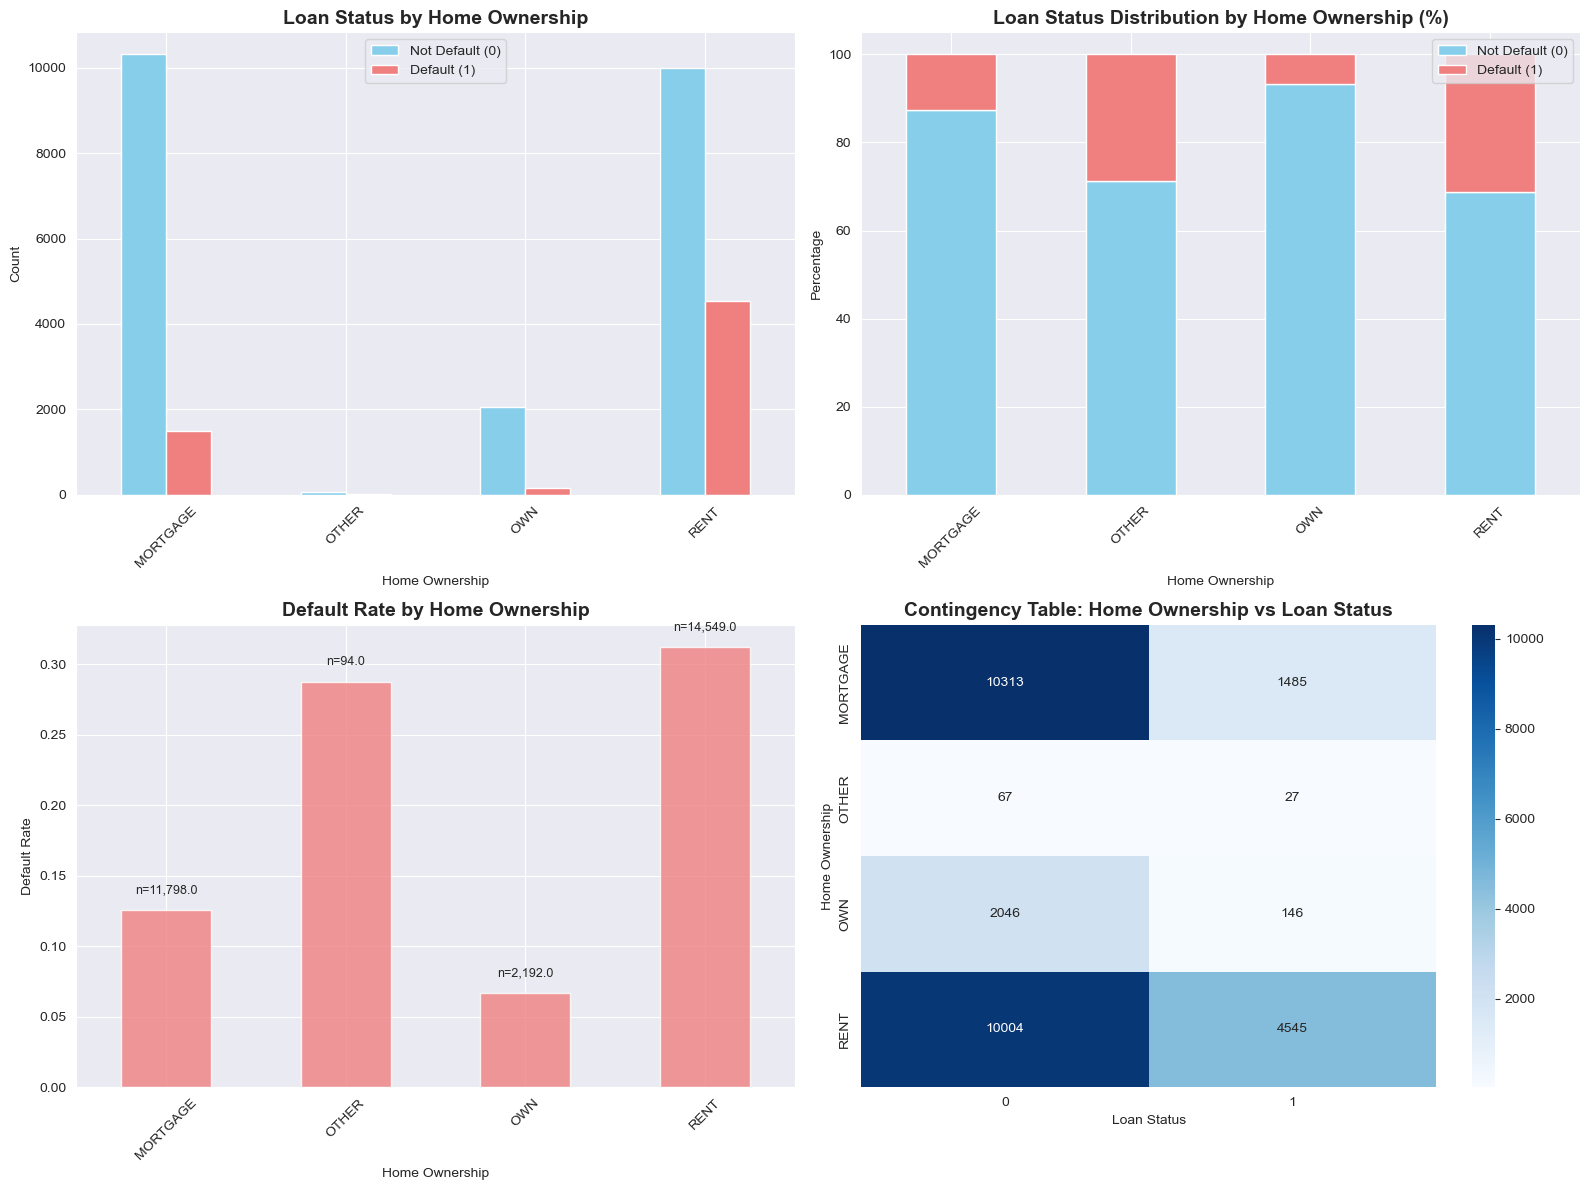

Detailed Analysis: Home Ownership vs Loan Status


RENT:
  Total Loans: 14,549
  Defaults: 4,545 (31.24%)
  Non-Defaults: 10,004 (68.76%)

OWN:
  Total Loans: 2,192
  Defaults: 146 (6.66%)
  Non-Defaults: 2,046 (93.34%)

MORTGAGE:
  Total Loans: 11,798
  Defaults: 1,485 (12.59%)
  Non-Defaults: 10,313 (87.41%)

OTHER:
  Total Loans: 94
  Defaults: 27 (28.72%)
  Non-Defaults: 67 (71.28%)

Chi-square Test for Independence:
  Chi-square statistic: 1652.3447
  p-value: 0.000000
  Degrees of freedom: 3
  Significant relationship: Yes (α = 0.05)


In [36]:
# analyzing the relationship between home ownership and loan status
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Grouped Bar Chart
home_loan_crosstab = pd.crosstab(df['person_home_ownership'], df['loan_status'])
home_loan_crosstab.plot(kind='bar', ax=axes[0,0], color=['skyblue', 'lightcoral'])
axes[0,0].set_title('Loan Status by Home Ownership', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Home Ownership')
axes[0,0].set_ylabel('Count')
axes[0,0].legend(['Not Default (0)', 'Default (1)'])
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Stacked Percentage Bar Chart
home_loan_pct = pd.crosstab(df['person_home_ownership'], df['loan_status'], normalize='index') * 100
home_loan_pct.plot(kind='bar', stacked=True, ax=axes[0,1], color=['skyblue', 'lightcoral'])
axes[0,1].set_title('Loan Status Distribution by Home Ownership (%)', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Home Ownership')
axes[0,1].set_ylabel('Percentage')
axes[0,1].legend(['Not Default (0)', 'Default (1)'])
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Default Rate by Home Ownership
default_rates_by_home = df.groupby('person_home_ownership')['loan_status'].agg(['mean', 'count'])
default_rates_by_home['mean'].plot(kind='bar', ax=axes[1,0], color='lightcoral', alpha=0.8)
axes[1,0].set_title('Default Rate by Home Ownership', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Home Ownership')
axes[1,0].set_ylabel('Default Rate')
axes[1,0].tick_params(axis='x', rotation=45)

# Add count labels on bars
for i, (ownership, row) in enumerate(default_rates_by_home.iterrows()):
    axes[1,0].text(i, row['mean'] + 0.01, f'n={row["count"]:,}',
                   ha='center', va='bottom', fontsize=9)

# 4. Heatmap of contingency table
sns.heatmap(home_loan_crosstab, annot=True, fmt='d', cmap='Blues', ax=axes[1,1])
axes[1,1].set_title('Contingency Table: Home Ownership vs Loan Status', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Loan Status')
axes[1,1].set_ylabel('Home Ownership')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("Detailed Analysis: Home Ownership vs Loan Status\n")
print("="*60)

for ownership in df['person_home_ownership'].unique():
    subset = df[df['person_home_ownership'] == ownership]
    total_loans = len(subset)
    defaults = sum(subset['loan_status'])
    non_defaults = total_loans - defaults
    default_rate = defaults / total_loans

    print(f"\n{ownership}:")
    print(f"  Total Loans: {total_loans:,}")
    print(f"  Defaults: {defaults:,} ({default_rate:.2%})")
    print(f"  Non-Defaults: {non_defaults:,} ({(1-default_rate):.2%})")

# Statistical significance test
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(home_loan_crosstab)
print(f"\n{'='*60}")
print(f"Chi-square Test for Independence:")
print(f"  Chi-square statistic: {chi2:.4f}")
print(f"  p-value: {p_value:.6f}")
print(f"  Degrees of freedom: {dof}")
print(f"  Significant relationship: {'Yes' if p_value < 0.05 else 'No'} (α = 0.05)")

In [37]:
# creating loan-to-income ratio
df['loan_to_income_ratio'] = df['loan_amnt'] / df['person_income']

# creating loan-to-employment length ratio
df['loan_to_emp_length_ratio'] =  df['person_emp_length']/ df['loan_amnt']

# creating interest rate-to-loan amount ratio
df['int_rate_to_loan_amt_ratio'] = df['loan_int_rate'] / df['loan_amnt']

In [38]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length', 'age_group',
       'income_group', 'loan_amount_group', 'loan_to_income_ratio',
       'loan_to_emp_length_ratio', 'int_rate_to_loan_amt_ratio'],
      dtype='object')

In [39]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,loan_to_income_ratio,loan_to_emp_length_ratio,int_rate_to_loan_amt_ratio
count,28633.000000,2.863300e+04,28633.00000,28633.000000,28633.000000,28633.000000,28633.000000,28633.000000,28633.000000,28633.000000,28633.000000
mean,27.709741,6.642964e+04,4.78867,9656.565851,11.039841,0.216638,0.169503,5.792757,0.169863,0.000767,0.001866
std,6.163130,5.155164e+04,4.15470,6329.755492,3.229529,0.411961,0.106389,4.035676,0.106664,0.001077,0.001868
min,20.000000,4.000000e+03,0.00000,500.000000,5.420000,0.000000,0.000000,2.000000,0.001282,0.000000,0.000200
25%,23.000000,3.945600e+04,2.00000,5000.000000,7.900000,0.000000,0.090000,3.000000,0.089286,0.000188,0.000792
50%,26.000000,5.590000e+04,4.00000,8000.000000,10.990000,0.000000,0.150000,4.000000,0.147059,0.000455,0.001273
75%,30.000000,8.000000e+04,7.00000,12500.000000,13.480000,0.000000,0.230000,8.000000,0.227907,0.000941,0.002173
max,80.000000,2.039784e+06,123.00000,35000.000000,23.220000,1.000000,0.830000,30.000000,0.830000,0.021000,0.022820


#### Splitting the Data into training and testing sets

In [40]:
X = df.drop(columns=['loan_status'])
y = df['loan_status']

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (22906, 17)
Testing set shape: (5727, 17)


In [42]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22906 entries, 5754 to 26896
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   person_age                  22906 non-null  int64   
 1   person_income               22906 non-null  int64   
 2   person_home_ownership       22906 non-null  object  
 3   person_emp_length           22906 non-null  float64 
 4   loan_intent                 22906 non-null  object  
 5   loan_grade                  22906 non-null  object  
 6   loan_amnt                   22906 non-null  int64   
 7   loan_int_rate               22906 non-null  float64 
 8   loan_percent_income         22906 non-null  float64 
 9   cb_person_default_on_file   22906 non-null  object  
 10  cb_person_cred_hist_length  22906 non-null  int64   
 11  age_group                   22880 non-null  category
 12  income_group                22906 non-null  category
 13  loan_amount_group 

In [43]:
# specifying categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

In [44]:
categorical_cols

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file', 'age_group', 'income_group',
       'loan_amount_group'],
      dtype='object')

In [45]:
numerical_cols

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'loan_to_income_ratio', 'loan_to_emp_length_ratio',
       'int_rate_to_loan_amt_ratio'],
      dtype='object')

In [46]:
# encoding categorical variables using one-hot encoding
from sklearn.preprocessing import OneHotEncoder

one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
one_hot_encoder.fit(X_train[categorical_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [47]:
one_hot_encoder.categories_

[array(['MORTGAGE', 'OTHER', 'OWN', 'RENT'], dtype=object),
 array(['DEBTCONSOLIDATION', 'EDUCATION', 'HOMEIMPROVEMENT', 'MEDICAL',
        'PERSONAL', 'VENTURE'], dtype=object),
 array(['A', 'B', 'C', 'D', 'E', 'F', 'G'], dtype=object),
 array(['N', 'Y'], dtype=object),
 array(['20-25', '26-35', '36-45', '46-55', '56-65', nan], dtype=object),
 array(['high', 'high-middle', 'low', 'low-middle', 'middle'], dtype=object),
 array(['large', 'medium', 'small', 'very large'], dtype=object)]

In [48]:
# transform categorical columns
encoded_col_names = one_hot_encoder.get_feature_names_out(categorical_cols)

X_train_cat_ohe = pd.DataFrame(
    one_hot_encoder.transform(X_train[categorical_cols]),
    columns=encoded_col_names,
    index=X_train.index
)

X_test_cat_ohe = pd.DataFrame(
    one_hot_encoder.transform(X_test[categorical_cols]),
    columns=encoded_col_names,
    index=X_test.index
)

# combining numerical + encoded categorical columns
X_train = pd.concat([X_train[numerical_cols], X_train_cat_ohe], axis=1)
X_test = pd.concat([X_test[numerical_cols], X_test_cat_ohe], axis=1)

In [49]:
X_train.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'loan_to_income_ratio', 'loan_to_emp_length_ratio',
       'int_rate_to_loan_amt_ratio', 'person_home_ownership_MORTGAGE',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'loan_grade_A', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D',
       'loan_grade_E', 'loan_grade_F', 'loan_grade_G',
       'cb_person_default_on_file_N', 'cb_person_default_on_file_Y',
       'age_group_20-25', 'age_group_26-35', 'age_group_36-45',
       'age_group_46-55', 'age_group_56-65', 'age_group_nan',
       'income_group_high', 'income_group_high-middle', 'income_group_low',
       'income_group_low-middle', 'income_group

In [50]:
X_train.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_to_income_ratio,loan_to_emp_length_ratio,int_rate_to_loan_amt_ratio,...,age_group_nan,income_group_high,income_group_high-middle,income_group_low,income_group_low-middle,income_group_middle,loan_amount_group_large,loan_amount_group_medium,loan_amount_group_small,loan_amount_group_very large
5754,26,30000,3.0,5400,10.00,0.18,4,0.180000,0.000556,0.001852,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
20397,34,45000,2.0,4500,16.95,0.10,10,0.100000,0.000444,0.003767,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
14551,25,110000,1.0,10000,12.69,0.09,3,0.090909,0.000100,0.001269,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5439,23,56016,4.0,5000,15.13,0.09,3,0.089260,0.000800,0.003026,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6632,26,45928,5.0,6000,7.90,0.13,4,0.130639,0.000833,0.001317,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [51]:
# scaling numerical features using standard scaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [52]:
# checking the distribution of numerical features after scaling
X_train.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_to_income_ratio,loan_to_emp_length_ratio,int_rate_to_loan_amt_ratio,...,age_group_nan,income_group_high,income_group_high-middle,income_group_low,income_group_low-middle,income_group_middle,loan_amount_group_large,loan_amount_group_medium,loan_amount_group_small,loan_amount_group_very large
count,2.290600e+04,2.290600e+04,2.290600e+04,2.290600e+04,2.290600e+04,2.290600e+04,2.290600e+04,2.290600e+04,2.290600e+04,2.290600e+04,...,22906.000000,22906.000000,22906.000000,22906.000000,22906.000000,22906.000000,22906.000000,22906.000000,22906.000000,22906.000000
mean,1.935644e-16,6.638267e-17,6.607247e-17,5.583589e-17,1.063984e-16,5.087270e-17,-2.605675e-17,1.284225e-16,-1.284225e-16,1.293531e-16,...,0.001135,0.128918,0.147822,0.070025,0.356151,0.297084,0.187462,0.372261,0.287567,0.152711
std,1.000022e+00,1.000022e+00,1.000022e+00,1.000022e+00,1.000022e+00,1.000022e+00,1.000022e+00,1.000022e+00,1.000022e+00,1.000022e+00,...,0.033672,0.335117,0.354931,0.255195,0.478871,0.456984,0.390290,0.483418,0.452638,0.359717
min,-1.254037e+00,-1.231652e+00,-1.139184e+00,-1.445382e+00,-1.738323e+00,-1.593103e+00,-9.417964e-01,-1.559252e+00,-7.124892e-01,-8.895256e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.656360e-01,-5.323291e-01,-6.619030e-01,-7.316536e-01,-9.711157e-01,-7.455623e-01,-6.933965e-01,-7.589504e-01,-5.408982e-01,-5.737627e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-2.772352e-01,-2.174229e-01,-1.846219e-01,-2.558344e-01,-1.520047e-02,-1.805352e-01,-4.449966e-01,-2.109937e-01,-2.900115e-01,-3.183485e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.739658e-01,2.738444e-01,5.312998e-01,4.182429e-01,7.551001e-01,5.728342e-01,5.486032e-01,5.444350e-01,1.602347e-01,1.709117e-01,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000
max,8.188378e+00,3.398904e+01,2.821360e+01,4.026539e+00,3.768244e+00,6.223105e+00,6.013402e+00,6.204283e+00,1.555290e+01,1.111935e+01,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

In [54]:
# initializing models
svc = SVC()
knc = KNeighborsClassifier()
# mnb = MultinomialNB()
dtc = DecisionTreeClassifier()
lrc = LogisticRegression()
rfc = RandomForestClassifier()
abc = AdaBoostClassifier()
gbdt = GradientBoostingClassifier()
xgb = XGBClassifier()
lgb = LGBMClassifier()

In [55]:
# creating a dictionary of classifiers for easy access
classifiers = {
    'SVC': svc,
    'KNN': knc,
    # 'MultinomialNB': mnb,
    'DecisionTree': dtc,
    'LogisticRegression': lrc,
    'RandomForest': rfc,
    'AdaBoost': abc,
    'GradientBoosting': gbdt,
    'XGBoost': xgb,
    'LightGBM': lgb
}

In [56]:
def evaluate_classifier_with_cv(classifier, X, y, cv_folds=5, random_state=42):
    """
    Evaluate classifier using StratifiedKFold cross-validation
    """
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    # cross-validation scores
    cv_accuracy = cross_val_score(classifier, X, y, cv=skf, scoring='accuracy')
    cv_precision = cross_val_score(classifier, X, y, cv=skf, scoring='precision')
    cv_recall = cross_val_score(classifier, X, y, cv=skf, scoring='recall')
    cv_f1 = cross_val_score(classifier, X, y, cv=skf, scoring='f1')

    # calculating means and standard deviations
    results = {
        'accuracy': {'mean': cv_accuracy.mean(), 'std': cv_accuracy.std()},
        'precision': {'mean': cv_precision.mean(), 'std': cv_precision.std()},
        'recall': {'mean': cv_recall.mean(), 'std': cv_recall.std()},
        'f1': {'mean': cv_f1.mean(), 'std': cv_f1.std()}
    }

    return results

In [57]:
# defining parameter grids for GridSearchCV hyperparameter tuning
param_grids = {
    'LogisticRegression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga'],
        'max_iter': [1000]
    },
    'SVC': {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear', 'rbf', 'poly'],
        'gamma': ['scale', 'auto', 0.001, 0.01],
        'probability': [True]  # needed for predict_proba
    },
    'DecisionTree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'criterion': ['gini', 'entropy']
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski']
    },
    'RandomForest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'AdaBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.5, 1.0],
        'algorithm': ['SAMME', 'SAMME.R']
    },
    'GradientBoosting': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    },
    'XGBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 0.9, 1.0]
    },
    'LightGBM': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 0.9, 1.0]
    }
}

In [58]:
# training models with default parameters
print("=== Step 1: Training Models with Default Parameters ===\n")

default_results = {}
trained_models = {}

for name, classifier in classifiers.items():
    print(f"\nTraining: {name}")

    classifier.fit(X_train, y_train)
    trained_models[name] = classifier

    y_pred = classifier.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    default_results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

print(f"\n{'='*60}")
print("STEP 1 COMPLETED - Basic Training Results Ready")
print(f"{'='*60}")

=== Step 1: Training Models with Default Parameters ===


Training: SVC
  Accuracy: 0.9188
  Precision: 0.9411
  Recall: 0.6582
  F1-Score: 0.7746

Training: KNN
  Accuracy: 0.8886
  Precision: 0.8103
  Recall: 0.6194
  F1-Score: 0.7021

Training: DecisionTree
  Accuracy: 0.8923
  Precision: 0.7323
  Recall: 0.7751
  F1-Score: 0.7531

Training: LogisticRegression
  Accuracy: 0.8828
  Precision: 0.7961
  Recall: 0.6013
  F1-Score: 0.6851

Training: RandomForest
  Accuracy: 0.9357
  Precision: 0.9710
  Recall: 0.7183
  F1-Score: 0.8258

Training: AdaBoost
  Accuracy: 0.8823
  Precision: 0.7626
  Recall: 0.6458
  F1-Score: 0.6994

Training: GradientBoosting
  Accuracy: 0.9303
  Precision: 0.9434
  Recall: 0.7142
  F1-Score: 0.8129

Training: XGBoost
  Accuracy: 0.9380
  Precision: 0.9633
  Recall: 0.7356
  F1-Score: 0.8342

Training: LightGBM
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4989, number of negative: 1791

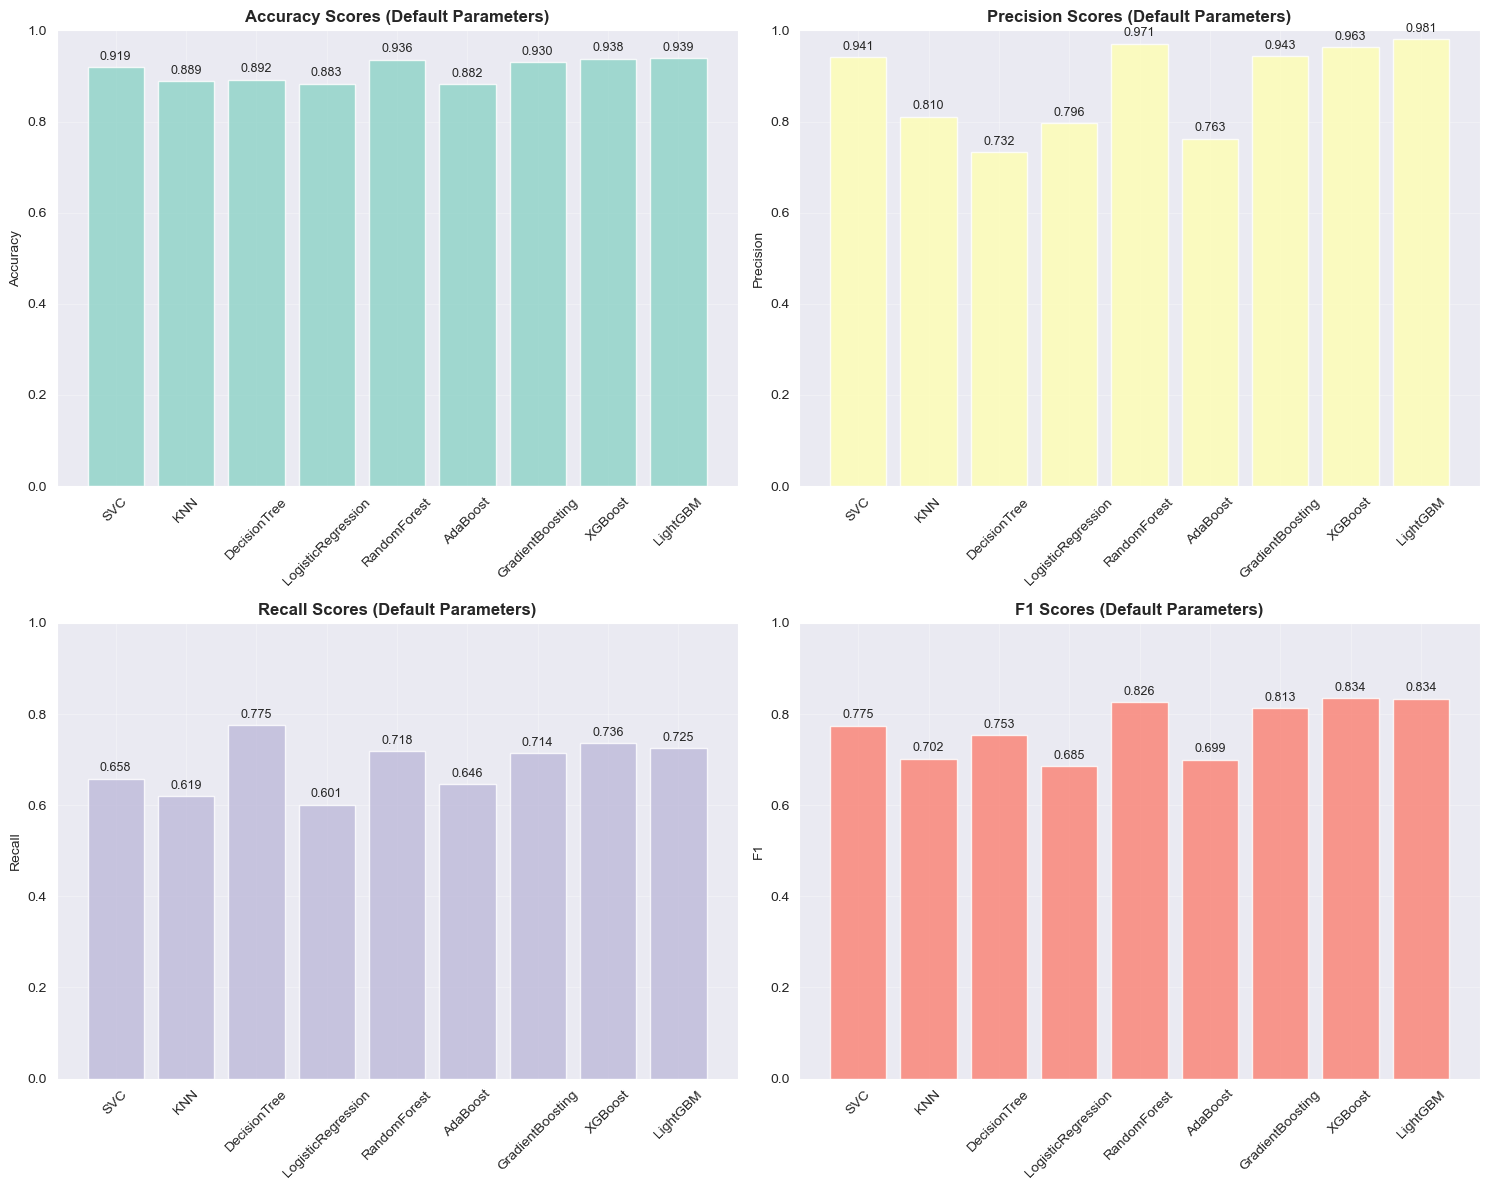


DEFAULT PARAMETERS RESULTS SUMMARY
             Model Accuracy Precision Recall F1-Score
               SVC   0.9188    0.9411 0.6582   0.7746
               KNN   0.8886    0.8103 0.6194   0.7021
      DecisionTree   0.8923    0.7323 0.7751   0.7531
LogisticRegression   0.8828    0.7961 0.6013   0.6851
      RandomForest   0.9357    0.9710 0.7183   0.8258
          AdaBoost   0.8823    0.7626 0.6458   0.6994
  GradientBoosting   0.9303    0.9434 0.7142   0.8129
           XGBoost   0.9380    0.9633 0.7356   0.8342
          LightGBM   0.9387    0.9810 0.7249   0.8337

BEST PERFORMING MODELS BY METRIC (Default Parameters)
Best ACCURACY: LightGBM (0.9387)
Best PRECISION: LightGBM (0.9810)
Best RECALL: DecisionTree (0.7751)
Best F1: XGBoost (0.8342)


In [59]:
# visualizing the default training results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# preparing data for visualization
model_names = list(default_results.keys())
metrics = ['accuracy', 'precision', 'recall', 'f1']
metric_values = {metric: [default_results[name][metric] for name in model_names] for metric in metrics}

for idx, metric in enumerate(metrics):
    row, col = idx // 2, idx % 2
    ax = axes[row, col]

    bars = ax.bar(model_names, metric_values[metric], alpha=0.8, color=plt.cm.Set3(idx))

    ax.set_title(f'{metric.capitalize()} Scores (Default Parameters)', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{metric.capitalize()}')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

    for bar, value in zip(bars, metric_values[metric]):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Create comparison table
print("\n" + "="*80)
print("DEFAULT PARAMETERS RESULTS SUMMARY")
print("="*80)

comparison_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': [f"{default_results[name]['accuracy']:.4f}" for name in model_names],
    'Precision': [f"{default_results[name]['precision']:.4f}" for name in model_names],
    'Recall': [f"{default_results[name]['recall']:.4f}" for name in model_names],
    'F1-Score': [f"{default_results[name]['f1']:.4f}" for name in model_names]
})

print(comparison_df.to_string(index=False))

# best model identification
print(f"\n{'='*80}")
print("BEST PERFORMING MODELS BY METRIC (Default Parameters)")
print(f"{'='*80}")

for metric in metrics:
    best_idx = np.argmax([default_results[name][metric] for name in model_names])
    best_model = model_names[best_idx]
    best_score = default_results[best_model][metric]
    print(f"Best {metric.upper()}: {best_model} ({best_score:.4f})")

In [60]:
# cross-validation evaluation
print("=== Step 2: Cross-Validation Evaluation ===\n")

# setting StratifiedKFold for consistent evaluation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

# combining training and testing data for cross-validation
X_combined = pd.concat([X_train, X_test], axis=0)
y_combined = pd.concat([y_train, y_test], axis=0)

for name, classifier in classifiers.items():
    print(f"\nEvaluating: {name}")

    # Cross-Validation Evaluation
    cv_scores = evaluate_classifier_with_cv(classifier, X_combined, y_combined)
    cv_results[name] = cv_scores

    for metric, scores in cv_scores.items():
        print(f"   {metric.capitalize()}: {scores['mean']:.4f} ± {scores['std']:.4f}")

print(f"\n{'='*60}")
print("STEP 2 COMPLETED - Cross-Validation Results Ready")
print(f"{'='*60}")

=== Step 2: Cross-Validation Evaluation ===


Evaluating: SVC
   Accuracy: 0.9165 ± 0.0032
   Precision: 0.9338 ± 0.0099
   Recall: 0.6615 ± 0.0119
   F1: 0.7743 ± 0.0096

Evaluating: KNN
   Accuracy: 0.8827 ± 0.0035
   Precision: 0.8020 ± 0.0125
   Recall: 0.6087 ± 0.0084
   F1: 0.6921 ± 0.0088

Evaluating: DecisionTree
   Accuracy: 0.8903 ± 0.0036
   Precision: 0.7377 ± 0.0118
   Recall: 0.7677 ± 0.0057
   F1: 0.7498 ± 0.0020

Evaluating: LogisticRegression


c:\Users\isha1\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\isha1\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

   Accuracy: 0.8764 ± 0.0031
   Precision: 0.7845 ± 0.0108
   Recall: 0.5920 ± 0.0087
   F1: 0.6747 ± 0.0081

Evaluating: RandomForest
   Accuracy: 0.9325 ± 0.0024
   Precision: 0.9601 ± 0.0053
   Recall: 0.7185 ± 0.0067
   F1: 0.8220 ± 0.0052

Evaluating: AdaBoost
   Accuracy: 0.8753 ± 0.0021
   Precision: 0.7526 ± 0.0101
   Recall: 0.6324 ± 0.0096
   F1: 0.6872 ± 0.0050

Evaluating: GradientBoosting
   Accuracy: 0.9268 ± 0.0037
   Precision: 0.9425 ± 0.0112
   Recall: 0.7053 ± 0.0100
   F1: 0.8068 ± 0.0100

Evaluating: XGBoost
   Accuracy: 0.9344 ± 0.0021
   Precision: 0.9494 ± 0.0102
   Recall: 0.7367 ± 0.0059
   F1: 0.8296 ± 0.0051

Evaluating: LightGBM
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4962, number of negative: 17944
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000852 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e

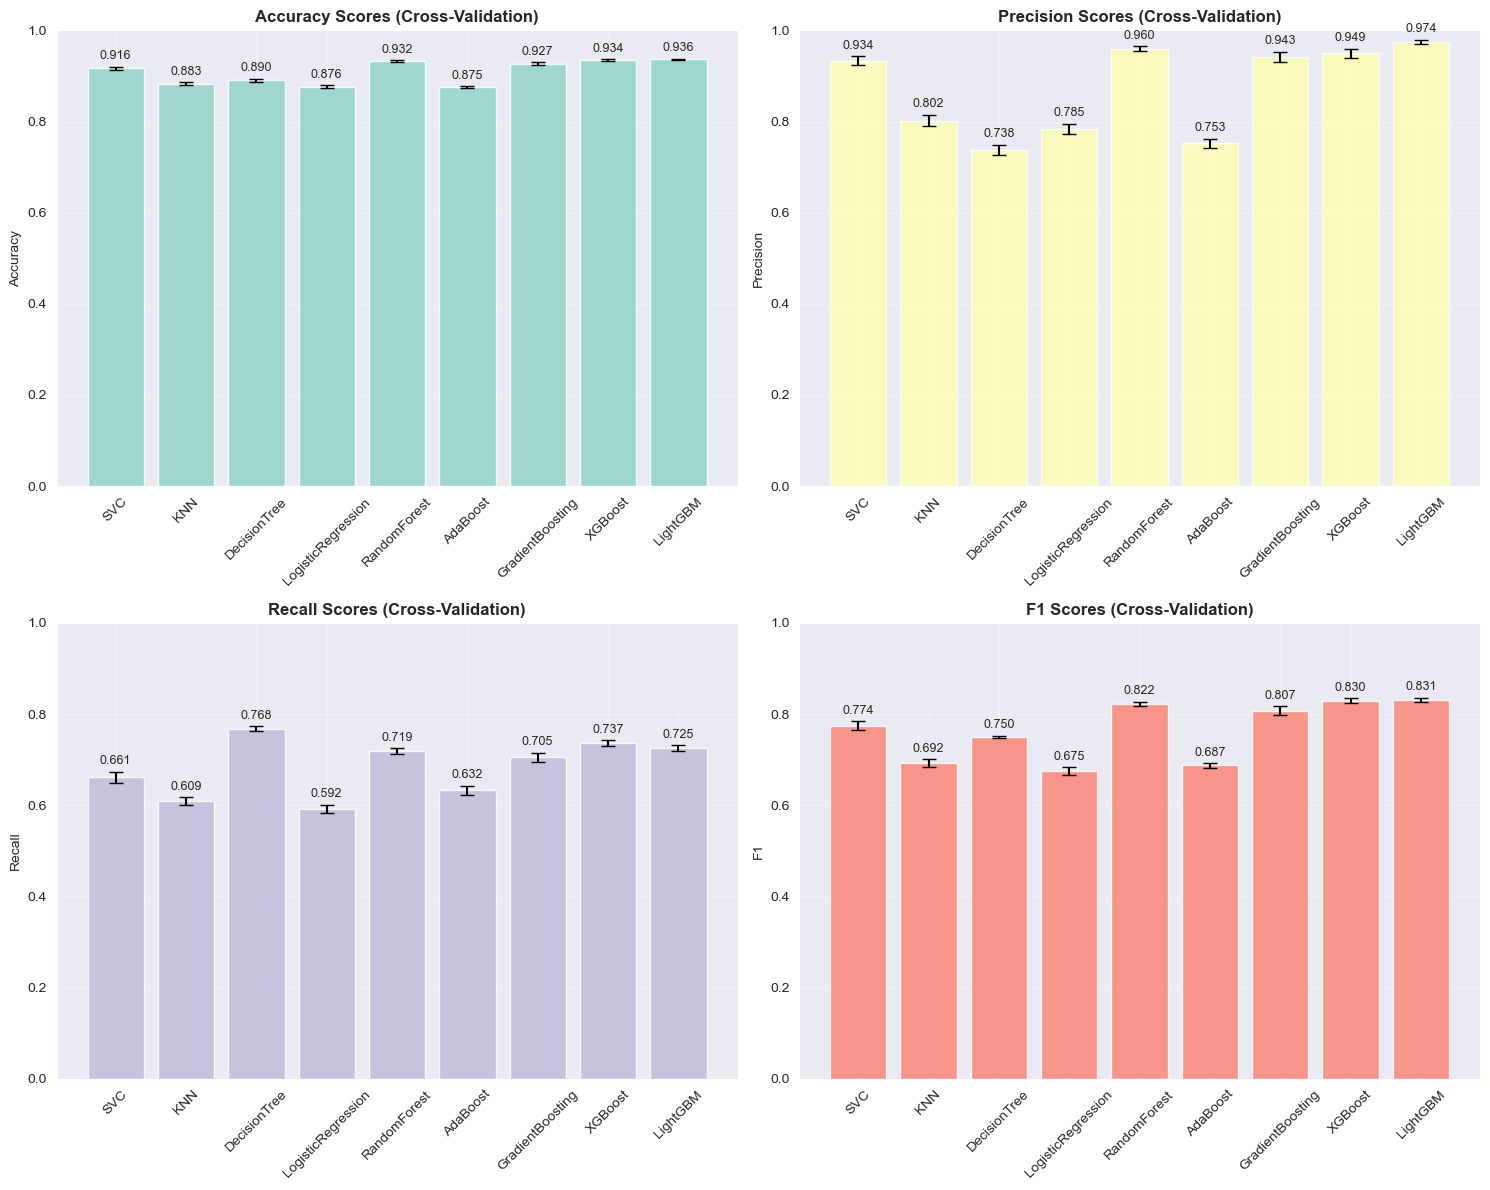


CROSS-VALIDATION RESULTS SUMMARY
             Model Accuracy (±std) Precision (±std)   Recall (±std) F1-Score (±std)
               SVC 0.9165 ± 0.0032  0.9338 ± 0.0099 0.6615 ± 0.0119 0.7743 ± 0.0096
               KNN 0.8827 ± 0.0035  0.8020 ± 0.0125 0.6087 ± 0.0084 0.6921 ± 0.0088
      DecisionTree 0.8903 ± 0.0036  0.7377 ± 0.0118 0.7677 ± 0.0057 0.7498 ± 0.0020
LogisticRegression 0.8764 ± 0.0031  0.7845 ± 0.0108 0.5920 ± 0.0087 0.6747 ± 0.0081
      RandomForest 0.9325 ± 0.0024  0.9601 ± 0.0053 0.7185 ± 0.0067 0.8220 ± 0.0052
          AdaBoost 0.8753 ± 0.0021  0.7526 ± 0.0101 0.6324 ± 0.0096 0.6872 ± 0.0050
  GradientBoosting 0.9268 ± 0.0037  0.9425 ± 0.0112 0.7053 ± 0.0100 0.8068 ± 0.0100
           XGBoost 0.9344 ± 0.0021  0.9494 ± 0.0102 0.7367 ± 0.0059 0.8296 ± 0.0051
          LightGBM 0.9362 ± 0.0017  0.9744 ± 0.0049 0.7247 ± 0.0067 0.8312 ± 0.0050

BEST PERFORMING MODELS BY METRIC (Cross-Validation)
Best ACCURACY: LightGBM (0.9362)
Best PRECISION: LightGBM (0.9744)
Best R

In [61]:
# visualizing cross-validation results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

model_names = list(cv_results.keys())
metrics = ['accuracy', 'precision', 'recall', 'f1']
metric_means = {metric: [cv_results[name][metric]['mean'] for name in model_names] for metric in metrics}
metric_stds = {metric: [cv_results[name][metric]['std'] for name in model_names] for metric in metrics}

for idx, metric in enumerate(metrics):
    row, col = idx // 2, idx % 2
    ax = axes[row, col]

    bars = ax.bar(model_names, metric_means[metric], yerr=metric_stds[metric],
                  capsize=5, alpha=0.8, color=plt.cm.Set3(idx))

    ax.set_title(f'{metric.capitalize()} Scores (Cross-Validation)', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{metric.capitalize()}')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

    for bar, mean_val, std_val in zip(bars, metric_means[metric], metric_stds[metric]):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + std_val + 0.01,
                f'{mean_val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "="*100)
print("CROSS-VALIDATION RESULTS SUMMARY")
print("="*100)

comparison_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy (±std)': [f"{cv_results[name]['accuracy']['mean']:.4f} ± {cv_results[name]['accuracy']['std']:.4f}" for name in model_names],
    'Precision (±std)': [f"{cv_results[name]['precision']['mean']:.4f} ± {cv_results[name]['precision']['std']:.4f}" for name in model_names],
    'Recall (±std)': [f"{cv_results[name]['recall']['mean']:.4f} ± {cv_results[name]['recall']['std']:.4f}" for name in model_names],
    'F1-Score (±std)': [f"{cv_results[name]['f1']['mean']:.4f} ± {cv_results[name]['f1']['std']:.4f}" for name in model_names]
})

print(comparison_df.to_string(index=False))

# best model identification
print(f"\n{'='*100}")
print("BEST PERFORMING MODELS BY METRIC (Cross-Validation)")
print(f"{'='*100}")

for metric in metrics:
    best_idx = np.argmax([cv_results[name][metric]['mean'] for name in model_names])
    best_model = model_names[best_idx]
    best_score = cv_results[best_model][metric]['mean']
    print(f"Best {metric.upper()}: {best_model} ({best_score:.4f})")

In [63]:
models_to_tune = ['DecisionTree', 'RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM']

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for name, classifier in classifiers.items():
    print(f"\n{'='*50}")
    print(f"Tuning: {name}")
    print(f"{'='*50}")

    if name in models_to_tune and name in param_grids:

        grid_search = GridSearchCV(
            classifier,
            param_grids[name],
            cv=skf,
            scoring='f1',
            n_jobs=-1,
            verbose=1
        )

        print("   Searching for best parameters...")
        grid_search.fit(X_combined, y_combined)

        best_models[name] = grid_search.best_estimator_
        grid_search_results[name] = {
            'best_params': grid_search.best_params_,
            'best_score': grid_search.best_score_,
            'cv_results': grid_search.cv_results_
        }

        print(f"   Best Parameters: {grid_search.best_params_}")
        print(f"   Best CV F1-Score: {grid_search.best_score_:.4f}")

    else:
        print(f"   Skipping hyperparameter tuning for {name}.")
        best_models[name] = classifier


Tuning: SVC
   Skipping hyperparameter tuning for SVC.

Tuning: KNN
   Skipping hyperparameter tuning for KNN.

Tuning: DecisionTree
   Searching for best parameters...
Fitting 3 folds for each of 90 candidates, totalling 270 fits
   Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}
   Best CV F1-Score: 0.8162

Tuning: LogisticRegression
   Skipping hyperparameter tuning for LogisticRegression.

Tuning: RandomForest
   Searching for best parameters...
Fitting 3 folds for each of 108 candidates, totalling 324 fits
   Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
   Best CV F1-Score: 0.8216

Tuning: AdaBoost
   Skipping hyperparameter tuning for AdaBoost.

Tuning: GradientBoosting
   Searching for best parameters...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
   Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
   Best CV F1-Scor

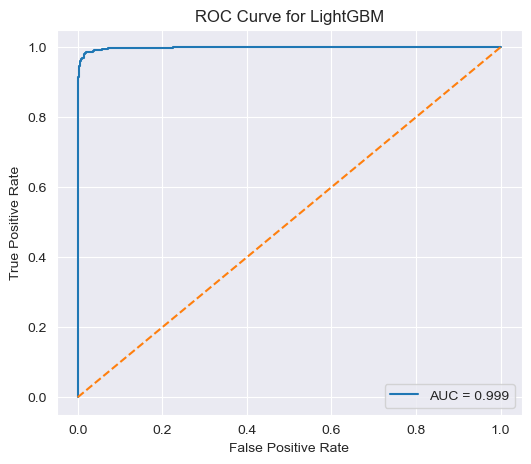

In [64]:
from sklearn.metrics import roc_curve, auc

y_prob = best_models['LightGBM'].predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for LightGBM")
plt.legend()
plt.show()

In [67]:
feature_importance = pd.Series(
    best_models['LightGBM'].feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

person_income                 1015
loan_int_rate                  729
loan_to_income_ratio           581
int_rate_to_loan_amt_ratio     544
loan_to_emp_length_ratio       521
person_age                     408
loan_amnt                      289
cb_person_cred_hist_length     268
loan_percent_income            261
person_emp_length              258
dtype: int32


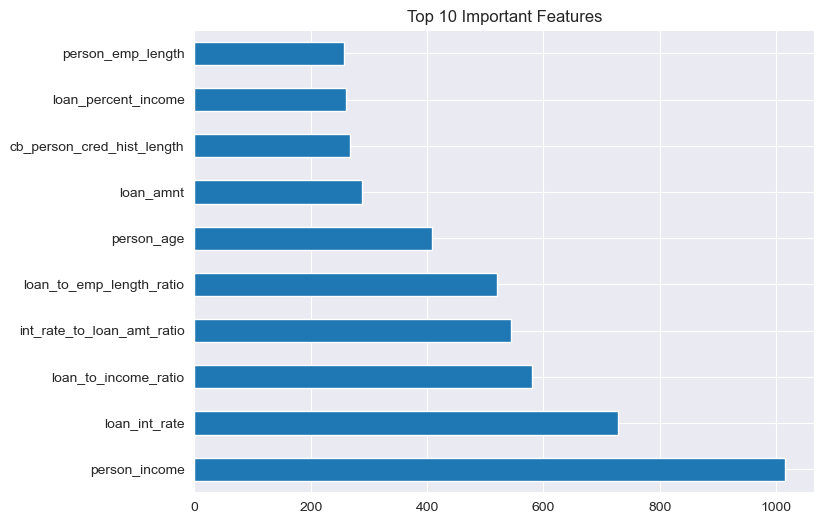

In [68]:
plt.figure(figsize=(8,6))
feature_importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

In [69]:
print("\n" + "="*80)
print("FINAL MODEL TESTING & PREDICTION")
print("="*80)

# select the best performing model
final_model = best_models['LightGBM']

print("\nUsing LightGBM as the final model for prediction.")

# predict on test dataset
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:,1]

# create results dataframe
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Default_Probability": y_prob
})

# classify probability into risk categories
results["Risk_Category"] = pd.cut(
    results["Default_Probability"],
    bins=[0, 0.3, 0.7, 1],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

print("\nSample Prediction Results:")
print(results.head(10))

print("\n" + "="*80)
print("SUMMARY OF TEST PREDICTIONS")
print("="*80)

print("Total Test Samples:", len(results))
print("Predicted High Risk:", (results["Predicted"] == 1).sum())
print("Predicted Low Risk:", (results["Predicted"] == 0).sum())

# show distribution of predicted risk categories
print("\nRisk Category Distribution:")
print(results["Risk_Category"].value_counts())

print("\n" + "="*80)
print("SAMPLE CUSTOMER RISK PREDICTION")
print("="*80)

# select one customer example from test data
sample_customer = X_test.iloc[[0]]

sample_prediction = final_model.predict(sample_customer)[0]
sample_probability = final_model.predict_proba(sample_customer)[0][1]

print("Predicted Class:", "High Risk" if sample_prediction == 1 else "Low Risk")
print(f"Default Probability: {sample_probability:.3f}")

print("\nModel Prediction Complete.")
print("="*80)


FINAL MODEL TESTING & PREDICTION

Using LightGBM as the final model for prediction.

Sample Prediction Results:
       Actual  Predicted  Default_Probability Risk_Category
23383       0          0             0.067769      Low Risk
6983        0          0             0.025328      Low Risk
11628       0          0             0.027244      Low Risk
30244       0          0             0.044793      Low Risk
25010       0          0             0.000072      Low Risk
16434       1          1             0.998907     High Risk
711         0          0             0.050213      Low Risk
24466       0          0             0.037277      Low Risk
29246       1          1             0.999814     High Risk
30870       0          0             0.000095      Low Risk

SUMMARY OF TEST PREDICTIONS
Total Test Samples: 5727
Predicted High Risk: 1059
Predicted Low Risk: 4668

Risk Category Distribution:
Risk_Category
Low Risk       4547
High Risk       953
Medium Risk     227
Name: count, dtype: